# Semantic Book Intelligence Research Lab
## Notebook 07 — Advanced Multi-label Genre Classification and Phase 1 Synthesis

**Phase:** Research Lane, Phase 1 — weak multi-label genre classification  
**Primary metric:** Macro F1, because every included genre should influence selection despite unequal support.  
**Primary question:** Can classical/E5 score fusion or task-specific multilingual E5 fine-tuning improve grouped cross-validated Macro F1 by at least **0.01** over the scaled classical baseline without unacceptable rare-genre or language-slice regressions?

This notebook is the bounded closing experiment for Phase 1. It compares a frozen Word + Character TF-IDF baseline, a leakage-safe classical/E5 score fusion, and one multilingual encoder under two predeclared losses. Semantic search and neighbor evaluation remain deferred to Phase 2.


## Execution contract and decision rules

Run the notebook sequentially in the `semantic_books` kernel. Candidate selection uses only the **18,462-book Notebook 06 development partition**; the closed Notebook 06 test is neither loaded nor reused. The final comparison is made once on a newly sampled, work-group-disjoint closing holdout after the candidate has been locked.

- The frozen classical control uses the Notebook 06 choices: Word/Character TF-IDF, class-balanced Linear SVM, and `C=0.1`.
- Frozen multilingual E5 uses the cached 384-dimensional vectors and class-balanced Logistic Regression with `C=0.03`.
- Fusion weight and per-label thresholds are selected inside each outer training fold.
- Fine-tuning compares weighted binary cross-entropy with asymmetric loss under identical data, epochs, and optimizer settings.
- An advanced candidate must gain at least **0.01 Macro F1**, lose no more than **0.03 F1** on any of the three rarest genres, and lose no more than **0.03 Macro F1** in any sufficiently large language slice.

Fine-tuning is intentionally implemented with the installed PyTorch and Transformers packages; it does not require `datasets`, `accelerate`, or `peft`. A small smoke test reports throughput before the grouped fine-tuning study begins. Expected runtime is machine-dependent and may be several hours on Apple MPS; fold-level caches make interrupted runs resumable.


## 1. Imports, configuration, and reproducibility


In [1]:
from __future__ import annotations

from html import unescape
from pathlib import Path
from time import perf_counter
import gc
import gzip
import hashlib
import json
import random
import re
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import huggingface_hub
# Preserve the import order that proved stable in Notebook 06's macOS Conda kernel.
import sentence_transformers
import sklearn
import torch
import transformers
from sentence_transformers import SentenceTransformer
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, ParameterGrid
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.svm import LinearSVC

# Freeze every selection, calibration, resource, and holdout decision before results are visible.
RANDOM_STATE = 20260818
OUTER_CV_SPLITS = 3
INNER_CV_SPLITS = 2
FINAL_CALIBRATION_SIZE = 0.15
MATERIAL_MACRO_F1_GAIN = 0.01
MAX_GUARDRAIL_DECLINE = 0.03
MIN_CALIBRATION_GAIN = 0.005
MIN_LANGUAGE_SLICE_BOOKS = 250

# Reuse Notebook 06's selected regularization values so Notebook 07 tests new methods, not retuned controls.
CLASSICAL_C = 0.1
E5_LOGISTIC_C = 0.03
FUSION_CLASSICAL_WEIGHTS = [0.00, 0.25, 0.50, 0.75, 1.00]

# Pin the encoder revision and one bounded training recipe for reproducible fine-tuning comparisons.
E5_MODEL_ID = "intfloat/multilingual-e5-small"
E5_MODEL_REVISION = "fd1525a9fd15316a2d503bf26ab031a61d056e98"
FINE_TUNING_LOSSES = ["weighted_bce", "asymmetric"]
FINE_TUNING_EPOCHS = 1
FINE_TUNING_MAX_LENGTH = 384
FINE_TUNING_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
FINE_TUNING_LEARNING_RATE = 2e-5
FINE_TUNING_WEIGHT_DECAY = 0.01
UNFREEZE_LAST_ENCODER_LAYERS = 4
SMOKE_TEST_ROWS = 512
SMOKE_TEST_OPTIMIZER_STEPS = 12

# Fix the final sample and cache schema before the untouched closing cohort is constructed.
CLOSING_DESCRIPTION_SAMPLE_SIZE = 5_000
MIN_CLOSING_LABELED_BOOKS = 3_000
MIN_DESCRIPTION_WORDS = 20
EMBEDDING_BATCH_SIZE = 32
CACHE_SCHEMA_VERSION = 3

# Preserve the ten-label order used by Notebooks 04-06 so every score column remains comparable.
TARGET_GENRES = [
    "fiction",
    "history, historical fiction, biography",
    "romance",
    "non-fiction",
    "fantasy, paranormal",
    "mystery, thriller, crime",
    "young-adult",
    "children",
    "comics, graphic",
    "poetry",
]

# Resolve stable project locations whether execution starts from the repository root or notebook folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "goodreads"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures" / "notebook07"
MODELS_DIR = PROJECT_ROOT / "models" / "notebook07"

for directory in [INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FILES = {
    "raw_books": RAW_DIR / "goodreads_books.json.gz",
    "raw_genres": RAW_DIR / "goodreads_book_genres_initial.json.gz",
    "original_books": INTERIM_DIR / "books_sample.parquet",
    "scaled_books": INTERIM_DIR / "books_scaled_fresh_v2.parquet",
    "scaled_genres": INTERIM_DIR / "book_genres_scaled_fresh_v2.parquet",
    "scaled_split": PROCESSED_DIR / "research_split_v2.parquet",
    "e5_embeddings": PROCESSED_DIR / "book_transformer_embeddings_multilingual_e5_small_v2.parquet",
    "notebook06_summary": REPORTS_DIR / "notebook06_nested_summary.csv",
    "closing_books": INTERIM_DIR / "books_phase1_closing_holdout_v3.parquet",
    "closing_genres": INTERIM_DIR / "book_genres_phase1_closing_holdout_v3.parquet",
    "closing_manifest": MODELS_DIR / "closing_holdout_manifest_v3.json",
    "closing_embeddings": PROCESSED_DIR / "book_transformer_embeddings_multilingual_e5_small_closing_v3.parquet",
}

# Fail early if any frozen Notebook 06 input is absent instead of failing after expensive training begins.
required_inputs = [
    "raw_books", "raw_genres", "original_books", "scaled_books", "scaled_genres",
    "scaled_split", "e5_embeddings", "notebook06_summary",
]
missing_inputs = [str(FILES[name]) for name in required_inputs if not FILES[name].exists()]
if missing_inputs:
    raise FileNotFoundError(f"Missing required Notebook 06 inputs: {missing_inputs}")

# Prefer an available accelerator while retaining a deterministic CPU fallback.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

# Surface the runtime versions because tokenizer, estimator, and accelerator behavior can change across releases.
version_summary = pd.DataFrame(
    {
        "library": [
            "Python", "NumPy", "pandas", "scikit-learn", "PyTorch",
            "Transformers", "Sentence Transformers", "Hugging Face Hub",
            "Matplotlib", "seaborn",
        ],
        "version": [
            sys.version.split()[0], np.__version__, pd.__version__, sklearn.__version__,
            torch.__version__, transformers.__version__, sentence_transformers.__version__,
            huggingface_hub.__version__, matplotlib.__version__, sns.__version__,
        ],
    }
)
display(version_summary)
print(f"Training device: {DEVICE}; outer/inner grouped folds: {OUTER_CV_SPLITS}/{INNER_CV_SPLITS}")


,library,version
0,Python,3.12.13
1,NumPy,2.5.1
2,pandas,3.0.3
3,scikit-learn,1.9.0
4,PyTorch,2.13.0
5,Transformers,5.15.0
6,Sentence Transformers,5.7.0
7,Hugging Face Hub,1.27.0
8,Matplotlib,3.11.1
9,seaborn,0.13.2


Training device: mps; outer/inner grouped folds: 3/2


## 2. Reconstruct the development-only cohort

Notebook 07 reuses only the Notebook 06 `development` rows and the matching cached E5 vectors. The code validates row identity, work grouping, label order, and a stable fingerprint before any model is fit. The Notebook 06 test labels are never loaded into an evaluation object.


In [2]:
# Normalize identifiers before joins so numeric/string inference cannot silently break row alignment.
def normalize_identifier(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip()


def language_group(language_code: object) -> str:
    code_value = str(language_code or "").strip().lower().replace("_", "-")
    if not code_value or code_value in {"nan", "none"}:
        return "Unknown"
    if code_value in {"en", "eng", "en-us", "en-gb", "en-ca", "en-au"}:
        return "English"
    return "Non-English"


def dataframe_fingerprint(frame: pd.DataFrame, columns: list[str]) -> str:
    ordered = frame.loc[:, columns].sort_values(columns).astype(str)
    return hashlib.sha256(ordered.to_csv(index=False).encode("utf-8")).hexdigest()


# Load the scaled cohort, its frozen split, weak labels, and row-aligned E5 representation.
scaled_books = pd.read_parquet(FILES["scaled_books"]).copy()
scaled_genres = pd.read_parquet(FILES["scaled_genres"]).copy()
split_manifest = pd.read_parquet(FILES["scaled_split"]).copy()
e5_cache = pd.read_parquet(FILES["e5_embeddings"]).copy()

for frame in [scaled_books, scaled_genres, split_manifest, e5_cache]:
    frame["book_id"] = normalize_identifier(frame["book_id"])

# Select only development identities; Notebook 06 test rows never enter a Notebook 07 modeling object.
development_ids = set(
    split_manifest.loc[split_manifest["split"].eq("development"), "book_id"]
)
if not development_ids:
    raise ValueError("Notebook 06 development partition is empty.")

# Collapse long-form genre links into one deterministic multi-label list per book.
genre_lists = (
    scaled_genres.loc[scaled_genres["genre"].isin(TARGET_GENRES)]
    .groupby("book_id", sort=False)["genre"]
    .agg(lambda values: sorted(set(values)))
    .rename("genre_labels")
    .reset_index()
)

# Inner joins intentionally remove description rows without one of the ten target labels.
development = (
    scaled_books.loc[scaled_books["book_id"].isin(development_ids)]
    .merge(genre_lists, on="book_id", how="inner", validate="one_to_one")
    .merge(
        split_manifest.loc[
            split_manifest["split"].eq("development"),
            ["book_id", "work_group", "cohort_fingerprint"],
        ],
        on="book_id",
        how="inner",
        validate="one_to_one",
        suffixes=("", "_split"),
    )
    .sort_values("book_id")
    .reset_index(drop=True)
)
development["work_group"] = normalize_identifier(development["work_group"])
development["work_group_split"] = normalize_identifier(development["work_group_split"])
if not development["work_group"].equals(development["work_group_split"]):
    raise ValueError("Scaled books and split manifest disagree on one or more work groups.")
if development["cohort_fingerprint"].nunique() != 1:
    raise ValueError("Notebook 06 development rows do not share one cohort fingerprint.")
development["language_group"] = development["language_code"].map(language_group)

# Realign cached vectors by book ID rather than trusting their stored row order.
embedding_columns = [column for column in e5_cache if column.startswith("embedding_")]
aligned_embeddings = development[["book_id"]].merge(
    e5_cache.loc[e5_cache["split"].eq("development"), ["book_id", *embedding_columns]],
    on="book_id",
    how="left",
    validate="one_to_one",
)
if aligned_embeddings[embedding_columns].isna().any().any():
    raise ValueError("E5 cache is missing one or more Notebook 06 development rows.")

# Materialize text, dense features, labels, and grouping keys in one shared row order.
label_binarizer = MultiLabelBinarizer(classes=TARGET_GENRES)
label_binarizer.fit([TARGET_GENRES])
y_development = label_binarizer.transform(development["genre_labels"]).astype(np.int8)
x_text = development["clean_description"].to_numpy(dtype=object)
x_e5 = aligned_embeddings[embedding_columns].to_numpy(dtype=np.float32)
development_groups = development["work_group"].to_numpy(dtype=object)
DEVELOPMENT_FINGERPRINT = dataframe_fingerprint(development, ["book_id", "work_group"])

# Enforce the frozen cohort size and embedding width before cross-validation can proceed.
if len(development) != len(development_ids):
    raise ValueError("Development reconstruction lost labeled rows or included unexpected books.")
if len(development) != 18_462:
    raise ValueError(f"Expected 18,462 development books from Notebook 06; found {len(development):,}.")
if x_e5.shape != (len(development), 384):
    raise ValueError(f"Expected aligned E5 shape ({len(development)}, 384); found {x_e5.shape}.")

# Keep notebook output compact while exposing the dimensions most relevant to runtime and leakage.
cohort_summary = pd.DataFrame(
    {
        "measure": [
            "Development books", "Unique work groups", "Target genres",
            "E5 dimensions", "Median description words",
        ],
        "value": [
            len(development), development["work_group"].nunique(), len(TARGET_GENRES),
            x_e5.shape[1], int(development["text_word_count"].median()),
        ],
    }
)
display(cohort_summary)
print(f"Development fingerprint: {DEVELOPMENT_FINGERPRINT[:16]}…")


,measure,value
0,Development books,18462
1,Unique work groups,17782
2,Target genres,10
3,E5 dimensions,384
4,Median description words,131


Development fingerprint: b26141a2b733ca35…


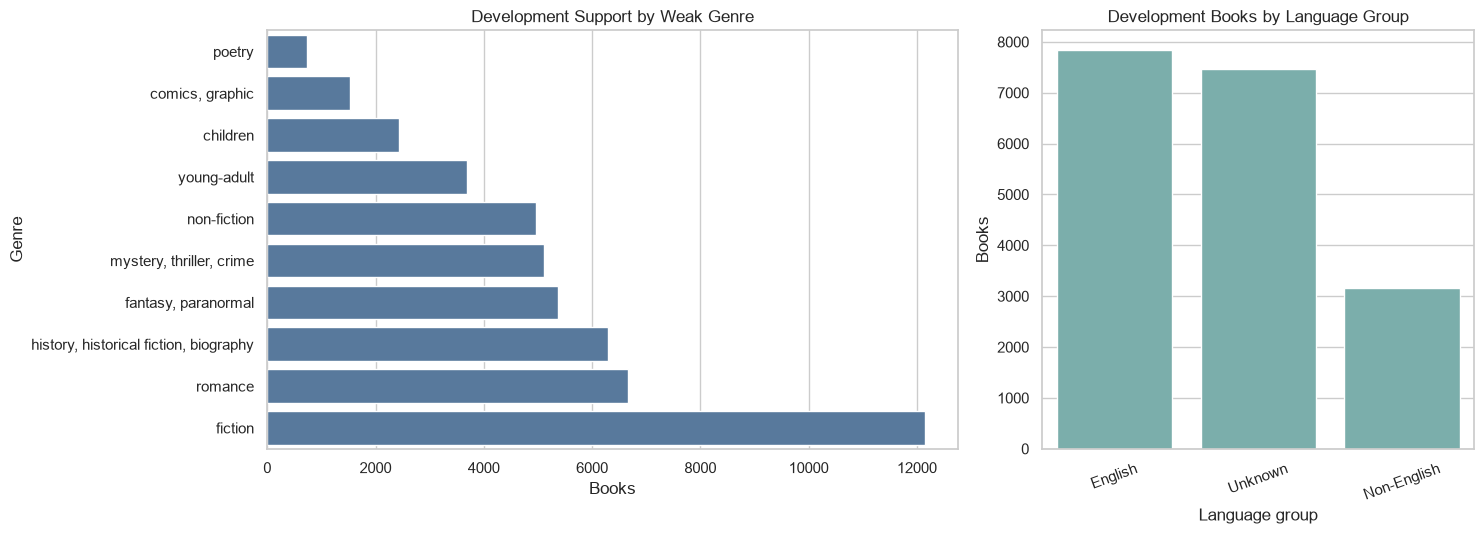

,genre,books
0,fiction,12150
1,romance,6661
2,"history, historical fiction, biography",6294
3,"fantasy, paranormal",5372
4,"mystery, thriller, crime",5105
5,non-fiction,4972
6,young-adult,3694
7,children,2432
8,"comics, graphic",1531
9,poetry,729


,language group,books
0,English,7833
1,Unknown,7461
2,Non-English,3168


In [3]:
# Quantify label and language imbalance before applying the later rare-label and slice guardrails.
label_support = pd.DataFrame(
    {"genre": TARGET_GENRES, "books": y_development.sum(axis=0)}
).sort_values("books", ascending=True)
language_support = (
    development["language_group"].value_counts().rename_axis("language group").reset_index(name="books")
)

# Side-by-side categorical views establish the imbalance and language guardrails used later.
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.6, 1]})
sns.barplot(data=label_support, x="books", y="genre", color="#4C78A8", ax=axes[0])
axes[0].set(title="Development Support by Weak Genre", xlabel="Books", ylabel="Genre")
sns.barplot(data=language_support, x="language group", y="books", color="#72B7B2", ax=axes[1])
axes[1].set(title="Development Books by Language Group", xlabel="Language group", ylabel="Books")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "development_label_and_language_support.png", dpi=160, bbox_inches="tight")
plt.show()

display(label_support.sort_values("books", ascending=False).reset_index(drop=True))
display(language_support)


## 3. Frozen controls, metrics, and threshold utilities

The sparse and dense controls exactly reuse Notebook 06's selected regularization values. Learned vocabularies, scaling, classifiers, score normalization, fusion weights, and thresholds are always fitted inside the relevant training boundary.


In [4]:
# Word n-grams capture topical phrases; character n-grams add robustness to spelling and morphology.
def word_vectorizer() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="word", lowercase=True, strip_accents="unicode", ngram_range=(1, 2),
        min_df=3, max_df=0.95, max_features=40_000, sublinear_tf=True, dtype=np.float32,
    )


def character_vectorizer() -> TfidfVectorizer:
    return TfidfVectorizer(
        analyzer="char_wb", lowercase=True, ngram_range=(3, 5), min_df=3,
        max_features=30_000, sublinear_tf=True, dtype=np.float32,
    )


def build_classical_pipeline() -> Pipeline:
    # Both vectorizers remain inside the pipeline so validation text never shapes the vocabulary.
    return Pipeline(
        [
            ("features", FeatureUnion([("word", word_vectorizer()), ("character", character_vectorizer())])),
            (
                "classifier",
                OneVsRestClassifier(
                    LinearSVC(
                        C=CLASSICAL_C, dual="auto", tol=1e-3, max_iter=10_000,
                        class_weight="balanced", random_state=RANDOM_STATE,
                    )
                ),
            ),
        ]
    )


# Standardize dense E5 dimensions inside each fold before fitting independent balanced genre classifiers.
def build_e5_logistic_pipeline() -> Pipeline:
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                OneVsRestClassifier(
                    LogisticRegression(
                        C=E5_LOGISTIC_C, solver="liblinear", max_iter=5_000,
                        class_weight="balanced", random_state=RANDOM_STATE,
                    )
                ),
            ),
        ]
    )


# Convert both estimator families to zero-centered continuous scores for shared calibration logic.
def continuous_scores(estimator: Pipeline, features: np.ndarray) -> np.ndarray:
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(features), dtype=np.float32)
    return np.asarray(estimator.predict_proba(features), dtype=np.float32) - 0.5


# Broadcast one threshold per genre so multi-label decisions preserve the fixed column order.
def predictions_from_thresholds(scores: np.ndarray, thresholds: np.ndarray) -> np.ndarray:
    return (scores >= thresholds.reshape(1, -1)).astype(np.int8)


def tune_per_label_thresholds(true_labels: np.ndarray, scores: np.ndarray) -> np.ndarray:
    # Quantile candidates adapt to each genre's score scale without consulting an outer fold.
    thresholds = np.zeros(scores.shape[1], dtype=np.float32)
    quantiles = np.linspace(0.01, 0.99, 81)
    for label_position in range(scores.shape[1]):
        label_scores = scores[:, label_position]
        candidates = np.unique(np.concatenate([np.quantile(label_scores, quantiles), [0.0]]))
        evaluated = [
            (
                f1_score(true_labels[:, label_position], label_scores >= threshold, zero_division=0),
                -abs(float(threshold)),
                float(threshold),
            )
            for threshold in candidates
        ]
        thresholds[label_position] = max(evaluated)[2]
    return thresholds


# Adopt tuned thresholds only when their calibration-only Macro F1 gain clears the frozen minimum.
def calibrated_thresholds(true_labels: np.ndarray, scores: np.ndarray):
    tuned = tune_per_label_thresholds(true_labels, scores)
    default_macro = f1_score(true_labels, scores >= 0.0, average="macro", zero_division=0)
    tuned_macro = f1_score(
        true_labels, predictions_from_thresholds(scores, tuned), average="macro", zero_division=0
    )
    if tuned_macro - default_macro >= MIN_CALIBRATION_GAIN:
        return tuned, "Tuned", tuned_macro - default_macro
    return np.zeros(scores.shape[1], dtype=np.float32), "Default", tuned_macro - default_macro


# Pair the primary Macro F1 with prevalence-weighted, exact-match, error-rate, and ranking views.
def multilabel_metrics(true_labels: np.ndarray, predictions: np.ndarray, scores: np.ndarray):
    return {
        "macro_f1": f1_score(true_labels, predictions, average="macro", zero_division=0),
        "micro_f1": f1_score(true_labels, predictions, average="micro", zero_division=0),
        "weighted_f1": f1_score(true_labels, predictions, average="weighted", zero_division=0),
        "subset_accuracy": accuracy_score(true_labels, predictions),
        "hamming_loss": hamming_loss(true_labels, predictions),
        "macro_average_precision": average_precision_score(true_labels, scores, average="macro"),
    }


# Standardize each genre's decision scale before blending heterogeneous classical and E5 scores.
def standardization_statistics(scores: np.ndarray):
    means = scores.mean(axis=0, dtype=np.float64).astype(np.float32)
    scales = scores.std(axis=0, dtype=np.float64).astype(np.float32)
    scales[scales < 1e-6] = 1.0
    return means, scales


def standardized_scores(scores: np.ndarray, means: np.ndarray, scales: np.ndarray) -> np.ndarray:
    return (scores - means.reshape(1, -1)) / scales.reshape(1, -1)


# Retain label-level precision and recall so aggregate gains can be checked for hidden regressions.
def per_genre_metrics(true_labels: np.ndarray, predictions: np.ndarray, candidate: str) -> pd.DataFrame:
    precision, recall, f1_values, support = precision_recall_fscore_support(
        true_labels, predictions, average=None, zero_division=0
    )
    return pd.DataFrame(
        {
            "candidate": candidate,
            "genre": TARGET_GENRES,
            "precision": precision,
            "recall": recall,
            "f1": f1_values,
            "support": support.astype(int),
        }
    )


## 4. Nested grouped evaluation of the frozen controls and score fusion

Each outer fold remains untouched while an inner grouped loop generates out-of-fold classical and E5 scores. The inner scores define score scaling, search the five predeclared fusion weights, and decide whether threshold calibration is worth adopting. This makes fusion a genuine validation experiment rather than a post-hoc average of outer-fold results.


In [5]:
# Materialize deterministic outer folds once so every candidate sees the same validation books.
outer_cv = GroupKFold(n_splits=OUTER_CV_SPLITS)
outer_splits = list(outer_cv.split(x_text, y_development, development_groups))
fold_assignment = np.full(len(development), -1, dtype=np.int8)
fold_rows = []

for fold_number, (outer_train, outer_valid) in enumerate(outer_splits, start=1):
    # Verify each work appears on only one side of the fold before recording assignments.
    train_groups = set(development_groups[outer_train])
    valid_groups = set(development_groups[outer_valid])
    if train_groups & valid_groups:
        raise ValueError(f"Work-group leakage detected in outer fold {fold_number}.")
    fold_assignment[outer_valid] = fold_number
    fold_rows.append(
        {
            "outer_fold": fold_number,
            "training_books": len(outer_train),
            "validation_books": len(outer_valid),
            "training_work_groups": len(train_groups),
            "validation_work_groups": len(valid_groups),
            "work_group_overlap": 0,
        }
    )

if (fold_assignment < 0).any():
    raise ValueError("Every development row must appear in exactly one outer validation fold.")

# Persist fold membership and the cohort fingerprint so later audits can reproduce every validation row.
cv_fold_manifest = development[["book_id", "work_group"]].copy()
cv_fold_manifest["outer_fold"] = fold_assignment
cv_fold_manifest["development_fingerprint"] = DEVELOPMENT_FINGERPRINT
cv_fold_manifest.to_parquet(PROCESSED_DIR / "research_cv_folds_v3.parquet", index=False)
display(pd.DataFrame(fold_rows))


,outer_fold,training_books,validation_books,training_work_groups,validation_work_groups,work_group_overlap
0,1,12308,6154,11855,5927,0
1,2,12308,6154,11855,5927,0
2,3,12308,6154,11854,5928,0


In [6]:
# Preallocate one out-of-fold score and prediction matrix per representation in the common row order.
n_books, n_labels = y_development.shape
classical_oof_scores = np.zeros((n_books, n_labels), dtype=np.float32)
e5_oof_scores = np.zeros((n_books, n_labels), dtype=np.float32)
fusion_oof_scores = np.zeros((n_books, n_labels), dtype=np.float32)
classical_oof_predictions = np.zeros((n_books, n_labels), dtype=np.int8)
e5_oof_predictions = np.zeros((n_books, n_labels), dtype=np.int8)
fusion_oof_predictions = np.zeros((n_books, n_labels), dtype=np.int8)
classical_e5_fold_results = []
fusion_search_rows = []
fusion_fold_parameters = []

for fold_number, (outer_train, outer_valid) in enumerate(outer_splits, start=1):
    fold_start = perf_counter()
    inner_classical_scores = np.zeros((len(outer_train), n_labels), dtype=np.float32)
    inner_e5_scores = np.zeros((len(outer_train), n_labels), dtype=np.float32)
    inner_groups = development_groups[outer_train]
    inner_cv = GroupKFold(n_splits=INNER_CV_SPLITS)

    # Inner out-of-fold scores are the only inputs allowed to tune E5 thresholds or fusion.
    for inner_train_relative, inner_valid_relative in inner_cv.split(
        outer_train, y_development[outer_train], inner_groups
    ):
        inner_train = outer_train[inner_train_relative]
        inner_valid = outer_train[inner_valid_relative]

        inner_classical = build_classical_pipeline()
        inner_classical.fit(x_text[inner_train], y_development[inner_train])
        inner_classical_scores[inner_valid_relative] = continuous_scores(
            inner_classical, x_text[inner_valid]
        )

        inner_e5 = build_e5_logistic_pipeline()
        inner_e5.fit(x_e5[inner_train], y_development[inner_train])
        inner_e5_scores[inner_valid_relative] = continuous_scores(inner_e5, x_e5[inner_valid])

    # Calibrate E5 and estimate modality-specific score scales using inner OOF evidence only.
    e5_thresholds, e5_policy, e5_calibration_gain = calibrated_thresholds(
        y_development[outer_train], inner_e5_scores
    )
    classical_means, classical_scales = standardization_statistics(inner_classical_scores)
    e5_means, e5_scales = standardization_statistics(inner_e5_scores)
    inner_classical_z = standardized_scores(inner_classical_scores, classical_means, classical_scales)
    inner_e5_z = standardized_scores(inner_e5_scores, e5_means, e5_scales)

    fold_fusion_candidates = []
    # ParameterGrid makes the bounded fusion hyperparameter search explicit and reproducible.
    for parameters in ParameterGrid({"classical_weight": FUSION_CLASSICAL_WEIGHTS}):
        classical_weight = float(parameters["classical_weight"])
        inner_fused = classical_weight * inner_classical_z + (1.0 - classical_weight) * inner_e5_z
        thresholds, policy, calibration_gain = calibrated_thresholds(
            y_development[outer_train], inner_fused
        )
        predictions = predictions_from_thresholds(inner_fused, thresholds)
        candidate_row = {
            "outer_fold": fold_number,
            "classical_weight": classical_weight,
            "inner_macro_f1": f1_score(
                y_development[outer_train], predictions, average="macro", zero_division=0
            ),
            "threshold_policy": policy,
            "calibration_gain": calibration_gain,
            "thresholds": thresholds,
        }
        fold_fusion_candidates.append(candidate_row)
        fusion_search_rows.append({key: value for key, value in candidate_row.items() if key != "thresholds"})

    # Prefer more classical weight only when Macro F1 is exactly tied.
    selected_fusion = max(
        fold_fusion_candidates,
        key=lambda row: (row["inner_macro_f1"], row["classical_weight"]),
    )

    # Refit both frozen controls on the complete outer-training fold after all inner choices are fixed.
    outer_classical = build_classical_pipeline()
    outer_classical.fit(x_text[outer_train], y_development[outer_train])
    classical_scores = continuous_scores(outer_classical, x_text[outer_valid])
    classical_predictions = (classical_scores >= 0.0).astype(np.int8)

    outer_e5 = build_e5_logistic_pipeline()
    outer_e5.fit(x_e5[outer_train], y_development[outer_train])
    e5_scores = continuous_scores(outer_e5, x_e5[outer_valid])
    e5_predictions = predictions_from_thresholds(e5_scores, e5_thresholds)

    # Apply the selected inner-fold weight and thresholds once to the untouched outer validation scores.
    fused_scores = (
        selected_fusion["classical_weight"]
        * standardized_scores(classical_scores, classical_means, classical_scales)
        + (1.0 - selected_fusion["classical_weight"])
        * standardized_scores(e5_scores, e5_means, e5_scales)
    )
    fused_predictions = predictions_from_thresholds(fused_scores, selected_fusion["thresholds"])

    # Write held-out results back to their original positions for later global slice analysis.
    classical_oof_scores[outer_valid] = classical_scores
    e5_oof_scores[outer_valid] = e5_scores
    fusion_oof_scores[outer_valid] = fused_scores
    classical_oof_predictions[outer_valid] = classical_predictions
    e5_oof_predictions[outer_valid] = e5_predictions
    fusion_oof_predictions[outer_valid] = fused_predictions

    fold_elapsed = perf_counter() - fold_start
    for candidate, predictions, scores, policy in [
        ("Classical TF-IDF", classical_predictions, classical_scores, "Default"),
        ("Frozen E5", e5_predictions, e5_scores, e5_policy),
        ("Classical + E5 fusion", fused_predictions, fused_scores, selected_fusion["threshold_policy"]),
    ]:
        classical_e5_fold_results.append(
            {
                "candidate": candidate,
                "outer_fold": fold_number,
                "validation_books": len(outer_valid),
                "threshold_policy": policy,
                # Shared inner fits serve all three candidates; divide elapsed time to avoid triple-counting.
                "fit_seconds": fold_elapsed / 3.0,
                **multilabel_metrics(y_development[outer_valid], predictions, scores),
            }
        )

    # Retain scaling and threshold provenance even though the displayed table remains intentionally compact.
    fusion_fold_parameters.append(
        {
            "outer_fold": fold_number,
            "classical_weight": selected_fusion["classical_weight"],
            "e5_weight": 1.0 - selected_fusion["classical_weight"],
            "inner_macro_f1": selected_fusion["inner_macro_f1"],
            "threshold_policy": selected_fusion["threshold_policy"],
            "e5_calibration_gain": e5_calibration_gain,
            "classical_score_mean": classical_means.tolist(),
            "classical_score_scale": classical_scales.tolist(),
            "e5_score_mean": e5_means.tolist(),
            "e5_score_scale": e5_scales.tolist(),
            "fusion_thresholds": selected_fusion["thresholds"].tolist(),
        }
    )
    print(
        f"Fold {fold_number}: fusion classical weight "
        f"{selected_fusion['classical_weight']:.2f}; "
        f"inner Macro F1 {selected_fusion['inner_macro_f1']:.4f}"
    )

classical_e5_fold_results = pd.DataFrame(classical_e5_fold_results)
fusion_search_results = pd.DataFrame(fusion_search_rows)
fusion_parameters = pd.DataFrame(fusion_fold_parameters)
display(classical_e5_fold_results.round(4))
display(fusion_parameters[["outer_fold", "classical_weight", "e5_weight", "inner_macro_f1", "threshold_policy"]].round(4))


Fold 1: fusion classical weight 0.50; inner Macro F1 0.6682
Fold 2: fusion classical weight 0.50; inner Macro F1 0.6595
Fold 3: fusion classical weight 0.50; inner Macro F1 0.6689


,candidate,outer_fold,validation_books,threshold_policy,fit_seconds,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Classical TF-IDF,1,6154,Default,20.7262,0.6388,0.7031,0.7043,0.2065,0.1612,0.6896
1,Frozen E5,1,6154,Tuned,20.7262,0.6527,0.7236,0.7209,0.2069,0.1566,0.6919
2,Classical + E5 fusion,1,6154,Tuned,20.7262,0.6743,0.7382,0.7369,0.2291,0.1468,0.7233
3,Classical TF-IDF,2,6154,Default,20.5821,0.6505,0.7150,0.7166,0.2179,0.1548,0.7046
4,Frozen E5,2,6154,Tuned,20.5821,0.6566,0.7263,0.7260,0.1916,0.1582,0.7007
5,Classical + E5 fusion,2,6154,Tuned,20.5821,0.6773,0.7406,0.7426,0.2257,0.1484,0.7379
6,Classical TF-IDF,3,6154,Default,20.7641,0.6448,0.7120,0.7134,0.2187,0.1568,0.6902
7,Frozen E5,3,6154,Tuned,20.7641,0.6471,0.7266,0.7245,0.2046,0.1543,0.6828
8,Classical + E5 fusion,3,6154,Tuned,20.7641,0.6720,0.7372,0.7386,0.2218,0.1493,0.7218


,outer_fold,classical_weight,e5_weight,inner_macro_f1,threshold_policy
0,1,0.5,0.5,0.6682,Tuned
1,2,0.5,0.5,0.6595,Tuned
2,3,0.5,0.5,0.6689,Tuned


## 5. Task-specific multilingual E5 fine-tuning

The encoder receives the same `query:`-prefixed descriptions used by Notebook 06 and a ten-output classification head. To bound memory and runtime, only the final four transformer layers and the new head are trainable; the tokenizer, lower encoder layers, maximum length, one-epoch budget, optimizer, and batch accumulation remain identical across both loss functions.

Weighted binary cross-entropy directly compensates for label imbalance. Asymmetric loss instead suppresses easy negative examples more strongly, testing whether rare positive genres benefit when the many negative label decisions contribute less gradient.


In [7]:
# Seed Python, NumPy, and PyTorch together so fold-level training is repeatable.
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Keep raw text in memory and tokenize by batch, avoiding a second full tokenized dataset copy.
class GenreTextDataset(Dataset):
    def __init__(self, texts: np.ndarray, labels: np.ndarray | None = None):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.float32)

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        # Match the E5 prefix used to generate Notebook 06's frozen dense representation.
        text = f"query: {self.texts[index]}"
        if self.labels is None:
            return text
        return text, self.labels[index]


# Add a lightweight ten-logit head above masked mean pooling of the multilingual encoder.
class E5GenreClassifier(nn.Module):
    def __init__(self, encoder: nn.Module, label_count: int):
        super().__init__()
        self.encoder = encoder
        self.dropout = nn.Dropout(0.10)
        self.classifier = nn.Linear(encoder.config.hidden_size, label_count)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        encoder_inputs = {"input_ids": input_ids, "attention_mask": attention_mask}
        if token_type_ids is not None:
            encoder_inputs["token_type_ids"] = token_type_ids
        encoded = self.encoder(**encoder_inputs)
        # Exclude padding tokens from the pooled book representation before classification.
        mask = attention_mask.unsqueeze(-1).to(encoded.last_hidden_state.dtype)
        pooled = (encoded.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.classifier(self.dropout(pooled))


# Down-weight easy negatives more strongly than positives to test a modern imbalance-aware objective.
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_negative: float = 4.0, gamma_positive: float = 1.0, clip: float = 0.05):
        super().__init__()
        self.gamma_negative = gamma_negative
        self.gamma_positive = gamma_positive
        self.clip = clip

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        positive_probabilities = torch.sigmoid(logits)
        negative_probabilities = 1.0 - positive_probabilities
        # Probability clipping prevents abundant easy negatives from dominating the loss.
        if self.clip:
            negative_probabilities = (negative_probabilities + self.clip).clamp(max=1.0)
        log_likelihood = (
            targets * torch.log(positive_probabilities.clamp(min=1e-8))
            + (1.0 - targets) * torch.log(negative_probabilities.clamp(min=1e-8))
        )
        probability = positive_probabilities * targets + negative_probabilities * (1.0 - targets)
        gamma = self.gamma_positive * targets + self.gamma_negative * (1.0 - targets)
        return -(log_likelihood * torch.pow(1.0 - probability, gamma)).mean()


# Load the pinned local checkpoint and train only the final encoder block plus classification head.
def build_fine_tuning_model(seed: int):
    seed_everything(seed)
    tokenizer = AutoTokenizer.from_pretrained(
        E5_MODEL_ID, revision=E5_MODEL_REVISION, local_files_only=True
    )
    encoder = AutoModel.from_pretrained(
        E5_MODEL_ID,
        revision=E5_MODEL_REVISION,
        local_files_only=True,
        # Eager attention supports training-time dropout on Apple MPS in this PyTorch build.
        attn_implementation="eager",
    )
    # Freeze the full backbone first, then selectively reopen the last configured layers.
    for parameter in encoder.parameters():
        parameter.requires_grad = False

    encoder_layers = encoder.encoder.layer
    for layer in encoder_layers[-UNFREEZE_LAST_ENCODER_LAYERS:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    model = E5GenreClassifier(encoder, len(TARGET_GENRES)).to(DEVICE)
    return tokenizer, model


# Dynamic batch padding reduces accelerator work compared with padding every book to 384 tokens.
def labeled_collate(tokenizer):
    def collate(batch):
        texts, labels = zip(*batch)
        tokens = tokenizer(
            list(texts), padding=True, truncation=True,
            max_length=FINE_TUNING_MAX_LENGTH, return_tensors="pt",
        )
        return tokens, torch.tensor(np.stack(labels), dtype=torch.float32)
    return collate


def text_collate(tokenizer):
    def collate(batch):
        return tokenizer(
            list(batch), padding=True, truncation=True,
            max_length=FINE_TUNING_MAX_LENGTH, return_tensors="pt",
        )
    return collate


# Compute positive weights from the current fit fold; validation prevalence never informs the loss.
def training_loss(loss_name: str, labels: np.ndarray, device: str):
    if loss_name == "weighted_bce":
        positives = labels.sum(axis=0)
        negatives = len(labels) - positives
        weights = np.clip(negatives / np.maximum(positives, 1), 1.0, 20.0)
        return nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(weights, dtype=torch.float32, device=device)
        )
    if loss_name == "asymmetric":
        return AsymmetricLoss()
    raise ValueError(f"Unknown fine-tuning loss: {loss_name}")


# Train one bounded fold model with gradient accumulation and optional early stopping for the smoke test.
def train_fine_tuned_e5(
    texts: np.ndarray,
    labels: np.ndarray,
    loss_name: str,
    seed: int,
    max_optimizer_steps: int | None = None,
):
    tokenizer, model = build_fine_tuning_model(seed)
    dataset = GenreTextDataset(texts, labels)
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        dataset,
        batch_size=FINE_TUNING_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=generator,
        collate_fn=labeled_collate(tokenizer),
    )
    # Optimize only trainable layers and the new head, keeping memory and update scope bounded.
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = AdamW(
        parameters, lr=FINE_TUNING_LEARNING_RATE, weight_decay=FINE_TUNING_WEIGHT_DECAY
    )
    criterion = training_loss(loss_name, labels, DEVICE)
    optimizer.zero_grad(set_to_none=True)
    optimizer_steps = 0
    seen_rows = 0
    start = perf_counter()

    model.train()
    for epoch in range(FINE_TUNING_EPOCHS):
        for batch_number, (tokens, batch_labels) in enumerate(loader, start=1):
            tokens = {key: value.to(DEVICE) for key, value in tokens.items()}
            batch_labels = batch_labels.to(DEVICE)
            logits = model(**tokens)
            loss = criterion(logits, batch_labels) / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            seen_rows += len(batch_labels)

            # Accumulate several small MPS-safe batches before clipping gradients and updating weights.
            should_step = batch_number % GRADIENT_ACCUMULATION_STEPS == 0 or batch_number == len(loader)
            if should_step:
                nn.utils.clip_grad_norm_(parameters, max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                optimizer_steps += 1
                if max_optimizer_steps is not None and optimizer_steps >= max_optimizer_steps:
                    break
        if max_optimizer_steps is not None and optimizer_steps >= max_optimizer_steps:
            break

    elapsed = perf_counter() - start
    log = {
        "loss_name": loss_name,
        "training_rows": len(texts),
        "seen_rows": seen_rows,
        "optimizer_steps": optimizer_steps,
        "training_seconds": elapsed,
        "rows_per_second": seen_rows / max(elapsed, 1e-9),
    }
    return tokenizer, model, log


# Disable gradient tracking and preserve row order while producing calibration or validation logits.
@torch.inference_mode()
def predict_fine_tuned_logits(tokenizer, model: nn.Module, texts: np.ndarray) -> np.ndarray:
    dataset = GenreTextDataset(texts)
    loader = DataLoader(
        dataset,
        batch_size=FINE_TUNING_BATCH_SIZE * 2,
        shuffle=False,
        num_workers=0,
        collate_fn=text_collate(tokenizer),
    )
    outputs = []
    model.eval()
    for tokens in loader:
        tokens = {key: value.to(DEVICE) for key, value in tokens.items()}
        outputs.append(model(**tokens).detach().cpu().numpy().astype(np.float32))
    return np.vstack(outputs)


# Release fold models promptly so repeated MPS/CUDA fits do not retain unnecessary memory.
def clear_accelerator_cache() -> None:
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE == "mps":
        torch.mps.empty_cache()


In [8]:
# A short real training run catches device, tokenizer, and memory problems before six CV fits.
smoke_positions = (
    development.sample(n=min(SMOKE_TEST_ROWS, len(development)), random_state=RANDOM_STATE).index.to_numpy()
)
smoke_tokenizer, smoke_model, smoke_log = train_fine_tuned_e5(
    x_text[smoke_positions],
    y_development[smoke_positions],
    loss_name="weighted_bce",
    seed=RANDOM_STATE,
    max_optimizer_steps=SMOKE_TEST_OPTIMIZER_STEPS,
)
smoke_logits = predict_fine_tuned_logits(
    smoke_tokenizer, smoke_model, x_text[smoke_positions[:64]]
)
if smoke_logits.shape != (min(64, len(smoke_positions)), len(TARGET_GENRES)):
    raise ValueError(f"Unexpected fine-tuning smoke-test output shape: {smoke_logits.shape}")

# Extrapolate observed throughput to all loss/fold fits as a planning estimate, not a measured runtime.
approximate_rows_per_run = len(development) * (1.0 - 1.0 / OUTER_CV_SPLITS) * (1.0 - FINAL_CALIBRATION_SIZE)
estimated_cv_hours = (
    approximate_rows_per_run * len(FINE_TUNING_LOSSES) * OUTER_CV_SPLITS
    / max(smoke_log["rows_per_second"], 1e-9)
    / 3600
)
smoke_summary = pd.DataFrame(
    [
        {
            **smoke_log,
            "device": DEVICE,
            "estimated_six_run_cv_hours": estimated_cv_hours,
            "status": "Passed",
        }
    ]
)
display(smoke_summary.round(3))
# Remove the disposable smoke model before allocating the first full cross-validation model.
del smoke_tokenizer, smoke_model
clear_accelerator_cache()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,loss_name,training_rows,seen_rows,optimizer_steps,training_seconds,rows_per_second,device,estimated_six_run_cv_hours,status
0,weighted_bce,512,384,12,5.491,69.927,mps,0.249,Passed


In [9]:
# Fingerprint every setting that can change fold logits so stale caches cannot be reused silently.
training_configuration = {
    "cache_schema_version": CACHE_SCHEMA_VERSION,
    "development_fingerprint": DEVELOPMENT_FINGERPRINT,
    "model_id": E5_MODEL_ID,
    "model_revision": E5_MODEL_REVISION,
    "outer_cv_splits": OUTER_CV_SPLITS,
    "calibration_size": FINAL_CALIBRATION_SIZE,
    "epochs": FINE_TUNING_EPOCHS,
    "max_length": FINE_TUNING_MAX_LENGTH,
    "batch_size": FINE_TUNING_BATCH_SIZE,
    "gradient_accumulation": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": FINE_TUNING_LEARNING_RATE,
    "weight_decay": FINE_TUNING_WEIGHT_DECAY,
    "unfrozen_encoder_layers": UNFREEZE_LAST_ENCODER_LAYERS,
    "losses": FINE_TUNING_LOSSES,
    "random_state": RANDOM_STATE,
}
FINE_TUNING_CONFIG_FINGERPRINT = hashlib.sha256(
    json.dumps(training_configuration, sort_keys=True).encode("utf-8")
).hexdigest()


def fine_tuning_cache_path(loss_name: str, fold_number: int) -> Path:
    return MODELS_DIR / f"fine_tuning_{loss_name}_outer_fold_{fold_number}_v3.npz"


# Trust a fold cache only when both its experiment fingerprint and held-out row positions match.
def load_cached_fine_tuning_fold(path: Path, validation_positions: np.ndarray):
    if not path.exists():
        return None
    cached = np.load(path, allow_pickle=False)
    if str(cached["config_fingerprint"].item()) != FINE_TUNING_CONFIG_FINGERPRINT:
        return None
    if not np.array_equal(cached["validation_positions"], validation_positions):
        return None
    return {
        "logits": cached["logits"].astype(np.float32),
        "predictions": cached["predictions"].astype(np.int8),
        "thresholds": cached["thresholds"].astype(np.float32),
        "threshold_policy": str(cached["threshold_policy"].item()),
        "calibration_gain": float(cached["calibration_gain"].item()),
        "training_seconds": float(cached["training_seconds"].item()),
        "cache_status": "loaded",
    }


# Preallocate complete OOF matrices so cached and newly generated folds share one downstream path.
fine_tuned_oof_scores = {
    loss_name: np.zeros((n_books, n_labels), dtype=np.float32)
    for loss_name in FINE_TUNING_LOSSES
}
fine_tuned_oof_predictions = {
    loss_name: np.zeros((n_books, n_labels), dtype=np.int8)
    for loss_name in FINE_TUNING_LOSSES
}
fine_tuning_fold_results = []
fine_tuning_threshold_rows = []

for fold_number, (outer_train, outer_valid) in enumerate(outer_splits, start=1):
    # Reserve calibration work groups inside each outer-training fold; outer validation remains untouched.
    calibration_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=FINAL_CALIBRATION_SIZE,
        random_state=RANDOM_STATE + fold_number,
    )
    fit_relative, calibration_relative = next(
        calibration_splitter.split(
            outer_train, y_development[outer_train], development_groups[outer_train]
        )
    )
    fit_positions = outer_train[fit_relative]
    calibration_positions = outer_train[calibration_relative]
    if set(development_groups[fit_positions]) & set(development_groups[calibration_positions]):
        raise ValueError(f"Fine-tuning fit/calibration group leakage in outer fold {fold_number}.")

    for loss_name in FINE_TUNING_LOSSES:
        cache_path = fine_tuning_cache_path(loss_name, fold_number)
        cached_result = load_cached_fine_tuning_fold(cache_path, outer_valid)

        # Train only missing or invalid folds, then calibrate thresholds before outer validation scoring.
        if cached_result is None:
            tokenizer, model, training_log = train_fine_tuned_e5(
                x_text[fit_positions],
                y_development[fit_positions],
                loss_name=loss_name,
                seed=RANDOM_STATE + fold_number,
            )
            calibration_logits = predict_fine_tuned_logits(
                tokenizer, model, x_text[calibration_positions]
            )
            validation_logits = predict_fine_tuned_logits(tokenizer, model, x_text[outer_valid])
            thresholds, threshold_policy, calibration_gain = calibrated_thresholds(
                y_development[calibration_positions], calibration_logits
            )
            validation_predictions = predictions_from_thresholds(validation_logits, thresholds)

            # Cache only held-out logits and calibration decisions; fold model weights are disposable.
            np.savez_compressed(
                cache_path,
                config_fingerprint=np.array(FINE_TUNING_CONFIG_FINGERPRINT),
                validation_positions=outer_valid,
                logits=validation_logits,
                predictions=validation_predictions,
                thresholds=thresholds,
                threshold_policy=np.array(threshold_policy),
                calibration_gain=np.array(calibration_gain),
                training_seconds=np.array(training_log["training_seconds"]),
            )
            cached_result = {
                "logits": validation_logits,
                "predictions": validation_predictions,
                "thresholds": thresholds,
                "threshold_policy": threshold_policy,
                "calibration_gain": calibration_gain,
                "training_seconds": training_log["training_seconds"],
                "cache_status": "generated",
            }
            del tokenizer, model
            clear_accelerator_cache()

        # Reassemble fold outputs in development-row order for fair candidate and slice comparisons.
        fine_tuned_oof_scores[loss_name][outer_valid] = cached_result["logits"]
        fine_tuned_oof_predictions[loss_name][outer_valid] = cached_result["predictions"]
        candidate_name = (
            "Fine-tuned E5 | Weighted BCE"
            if loss_name == "weighted_bce"
            else "Fine-tuned E5 | Asymmetric loss"
        )
        fine_tuning_fold_results.append(
            {
                "candidate": candidate_name,
                "outer_fold": fold_number,
                "validation_books": len(outer_valid),
                "threshold_policy": cached_result["threshold_policy"],
                "fit_seconds": cached_result["training_seconds"],
                "cache_status": cached_result["cache_status"],
                **multilabel_metrics(
                    y_development[outer_valid],
                    cached_result["predictions"],
                    cached_result["logits"],
                ),
            }
        )
        # Export genre-level thresholds and calibration gains for auditability across folds.
        for genre, threshold in zip(TARGET_GENRES, cached_result["thresholds"]):
            fine_tuning_threshold_rows.append(
                {
                    "candidate": candidate_name,
                    "outer_fold": fold_number,
                    "genre": genre,
                    "threshold": threshold,
                    "threshold_policy": cached_result["threshold_policy"],
                    "calibration_gain": cached_result["calibration_gain"],
                }
            )
        print(
            f"Fold {fold_number} / {loss_name}: {cached_result['cache_status']}; "
            f"Macro F1 {fine_tuning_fold_results[-1]['macro_f1']:.4f}"
        )

fine_tuning_fold_results = pd.DataFrame(fine_tuning_fold_results)
fine_tuning_thresholds = pd.DataFrame(fine_tuning_threshold_rows)
all_fold_results = pd.concat(
    [classical_e5_fold_results, fine_tuning_fold_results], ignore_index=True
)
display(fine_tuning_fold_results.round(4))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fold 1 / weighted_bce: generated; Macro F1 0.6232


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fold 1 / asymmetric: generated; Macro F1 0.6396


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fold 3 / weighted_bce: generated; Macro F1 0.6313


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fold 3 / asymmetric: generated; Macro F1 0.6282


,candidate,outer_fold,validation_books,threshold_policy,fit_seconds,cache_status,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Fine-tuned E5 | Weighted BCE,1,6154,Tuned,133.9732,generated,0.6232,0.6910,0.6961,0.1477,0.1769,0.6654
1,Fine-tuned E5 | Asymmetric loss,1,6154,Tuned,155.7639,generated,0.6396,0.7182,0.7174,0.2189,0.1548,0.6810
2,Fine-tuned E5 | Weighted BCE,2,6154,Tuned,148.1913,generated,0.6366,0.7119,0.7108,0.1856,0.1616,0.6664
3,Fine-tuned E5 | Asymmetric loss,2,6154,Tuned,140.8037,generated,0.6488,0.7256,0.7232,0.2225,0.1517,0.6896
4,Fine-tuned E5 | Weighted BCE,3,6154,Tuned,144.6497,generated,0.6313,0.7021,0.7031,0.1857,0.1646,0.6652
5,Fine-tuned E5 | Asymmetric loss,3,6154,Tuned,142.9069,generated,0.6282,0.7231,0.7203,0.2168,0.1537,0.6712


## 6. Candidate selection with rare-genre and language guardrails

Mean outer-fold Macro F1 determines the ranking, while out-of-fold predictions test whether an apparent aggregate gain hides unacceptable regressions. The classical baseline remains selected unless an advanced candidate passes all three predeclared rules.


In [10]:
# Aggregate fold metrics first, then apply the predeclared guardrails using out-of-fold predictions only.
candidate_oof_scores = {
    "Classical TF-IDF": classical_oof_scores,
    "Frozen E5": e5_oof_scores,
    "Classical + E5 fusion": fusion_oof_scores,
    "Fine-tuned E5 | Weighted BCE": fine_tuned_oof_scores["weighted_bce"],
    "Fine-tuned E5 | Asymmetric loss": fine_tuned_oof_scores["asymmetric"],
}
candidate_oof_predictions = {
    "Classical TF-IDF": classical_oof_predictions,
    "Frozen E5": e5_oof_predictions,
    "Classical + E5 fusion": fusion_oof_predictions,
    "Fine-tuned E5 | Weighted BCE": fine_tuned_oof_predictions["weighted_bce"],
    "Fine-tuned E5 | Asymmetric loss": fine_tuned_oof_predictions["asymmetric"],
}

candidate_summary = (
    all_fold_results.groupby("candidate", as_index=False)
    .agg(
        cv_macro_f1_mean=("macro_f1", "mean"),
        cv_macro_f1_std=("macro_f1", "std"),
        cv_micro_f1_mean=("micro_f1", "mean"),
        cv_macro_ap_mean=("macro_average_precision", "mean"),
        cv_hamming_loss_mean=("hamming_loss", "mean"),
        total_fit_seconds=("fit_seconds", "sum"),
    )
)

per_genre_oof = pd.concat(
    [
        per_genre_metrics(y_development, predictions, candidate)
        for candidate, predictions in candidate_oof_predictions.items()
    ],
    ignore_index=True,
)

# Score only sufficiently large language slices and labels with enough positives for meaningful F1.
language_rows = []
for language_name, positions in development.groupby("language_group").indices.items():
    positions = np.asarray(positions, dtype=int)
    if len(positions) < MIN_LANGUAGE_SLICE_BOOKS:
        continue
    supported_labels = y_development[positions].sum(axis=0) >= 20
    for candidate, predictions in candidate_oof_predictions.items():
        slice_macro = f1_score(
            y_development[positions][:, supported_labels],
            predictions[positions][:, supported_labels],
            average="macro",
            zero_division=0,
        )
        language_rows.append(
            {
                "candidate": candidate,
                "language_group": language_name,
                "books": len(positions),
                "supported_genres": int(supported_labels.sum()),
                "macro_f1": slice_macro,
            }
        )
language_slices = pd.DataFrame(language_rows)

# Anchor every material-gain and guardrail calculation to the frozen classical control.
baseline_macro = float(
    candidate_summary.loc[
        candidate_summary["candidate"].eq("Classical TF-IDF"), "cv_macro_f1_mean"
    ].iloc[0]
)
baseline_per_genre = (
    per_genre_oof.loc[per_genre_oof["candidate"].eq("Classical TF-IDF")]
    .set_index("genre")["f1"]
)
rare_genres = label_support.nsmallest(3, "books")["genre"].tolist()
baseline_language = (
    language_slices.loc[language_slices["candidate"].eq("Classical TF-IDF")]
    .set_index("language_group")["macro_f1"]
)

# Require aggregate improvement and both slice safeguards; the classical model is the explicit fallback.
selection_rows = []
for row in candidate_summary.itertuples(index=False):
    candidate_genre = per_genre_oof.loc[
        per_genre_oof["candidate"].eq(row.candidate)
    ].set_index("genre")["f1"]
    candidate_language = language_slices.loc[
        language_slices["candidate"].eq(row.candidate)
    ].set_index("language_group")["macro_f1"]
    macro_gain = row.cv_macro_f1_mean - baseline_macro
    worst_rare_delta = float((candidate_genre[rare_genres] - baseline_per_genre[rare_genres]).min())
    worst_language_delta = float((candidate_language - baseline_language).min())
    is_baseline = row.candidate == "Classical TF-IDF"
    eligible = is_baseline or (
        macro_gain >= MATERIAL_MACRO_F1_GAIN
        and worst_rare_delta >= -MAX_GUARDRAIL_DECLINE
        and worst_language_delta >= -MAX_GUARDRAIL_DECLINE
    )
    selection_rows.append(
        {
            "candidate": row.candidate,
            "cv_macro_f1_mean": row.cv_macro_f1_mean,
            "cv_macro_f1_std": row.cv_macro_f1_std,
            "macro_f1_gain_vs_classical": macro_gain,
            "worst_rare_genre_f1_delta": worst_rare_delta,
            "worst_language_macro_f1_delta": worst_language_delta,
            "eligible": eligible,
        }
    )

# Lock the highest-performing eligible candidate before any closing-holdout labels are constructed.
candidate_selection = pd.DataFrame(selection_rows).sort_values(
    ["eligible", "cv_macro_f1_mean"], ascending=[False, False]
).reset_index(drop=True)
SELECTED_CANDIDATE = candidate_selection.loc[0, "candidate"]
if not bool(candidate_selection.loc[0, "eligible"]):
    raise AssertionError("Selection logic must always retain the classical fallback.")

display(candidate_summary.sort_values("cv_macro_f1_mean", ascending=False).round(4))
display(candidate_selection.round(4))
print(f"Locked Phase 1 candidate before closing-holdout access: {SELECTED_CANDIDATE}")


,candidate,cv_macro_f1_mean,cv_macro_f1_std,cv_micro_f1_mean,cv_macro_ap_mean,cv_hamming_loss_mean,total_fit_seconds
0,Classical + E5 fusion,0.6746,0.0027,0.7387,0.7276,0.1482,62.0724
4,Frozen E5,0.6521,0.0048,0.7255,0.6918,0.1564,62.0724
1,Classical TF-IDF,0.6447,0.0058,0.7101,0.6948,0.1576,62.0724
2,Fine-tuned E5 | Asymmetric loss,0.6389,0.0103,0.7223,0.6806,0.1534,439.4745
3,Fine-tuned E5 | Weighted BCE,0.6304,0.0067,0.7017,0.6656,0.1677,426.8142


,candidate,cv_macro_f1_mean,cv_macro_f1_std,macro_f1_gain_vs_classical,worst_rare_genre_f1_delta,worst_language_macro_f1_delta,eligible
0,Classical + E5 fusion,0.6746,0.0027,0.0299,0.0284,0.0222,True
1,Classical TF-IDF,0.6447,0.0058,0.0000,0.0000,0.0000,True
2,Frozen E5,0.6521,0.0048,0.0074,-0.0365,-0.0040,False
3,Fine-tuned E5 | Asymmetric loss,0.6389,0.0103,-0.0058,-0.0703,-0.0229,False
4,Fine-tuned E5 | Weighted BCE,0.6304,0.0067,-0.0143,-0.0676,-0.0273,False


Locked Phase 1 candidate before closing-holdout access: Classical + E5 fusion


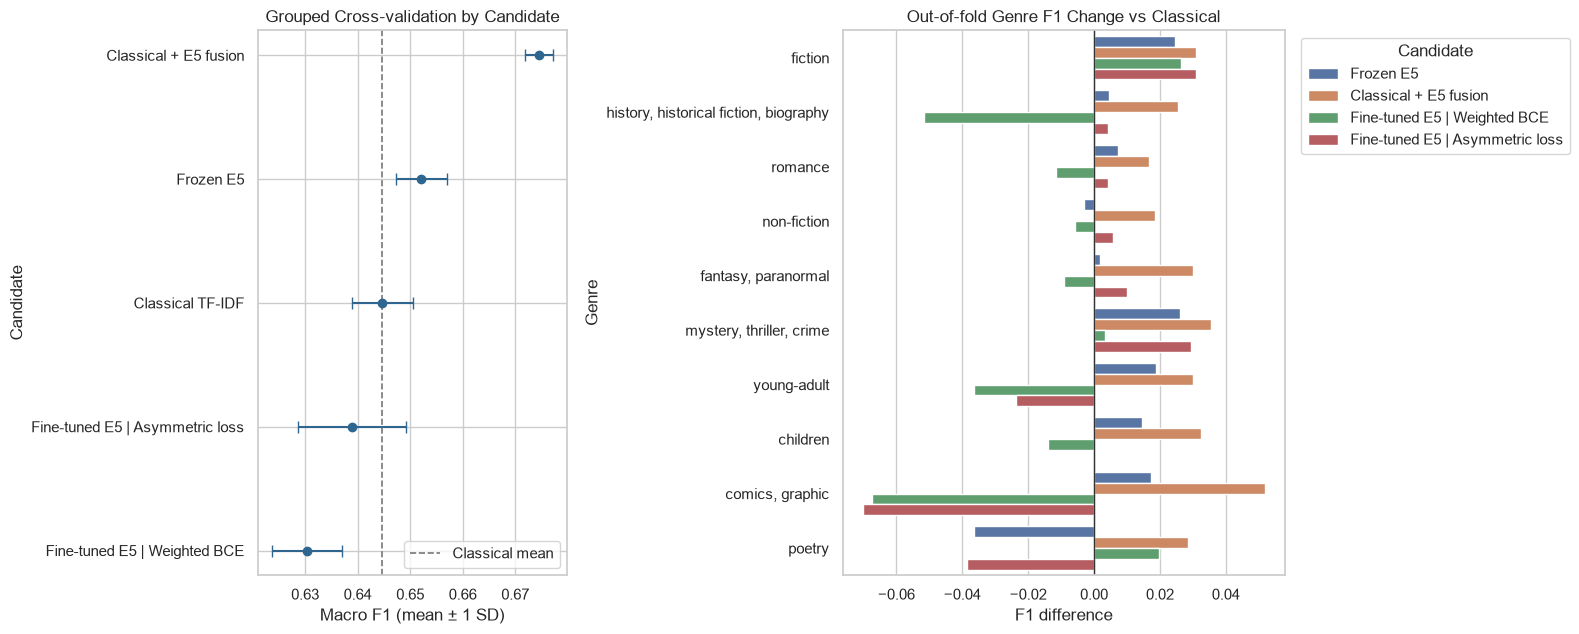

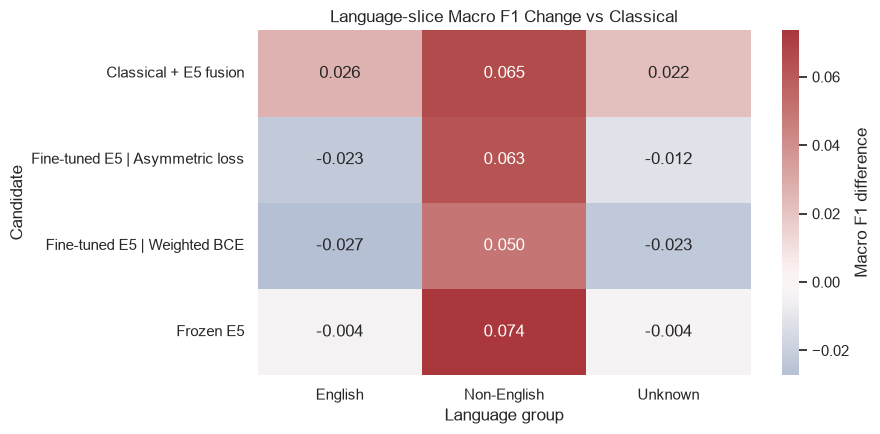

In [11]:
# Pair aggregate CV uncertainty with genre and language deltas so improvements cannot hide slice regressions.
ordered_candidates = candidate_summary.sort_values("cv_macro_f1_mean", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.05, 1.5]})

# Error bars show outer-fold variability rather than presenting only a point estimate.
axes[0].errorbar(
    ordered_candidates["cv_macro_f1_mean"],
    np.arange(len(ordered_candidates)),
    xerr=ordered_candidates["cv_macro_f1_std"],
    fmt="o",
    color="#2F6690",
    capsize=4,
)
axes[0].set_yticks(np.arange(len(ordered_candidates)), ordered_candidates["candidate"])
axes[0].axvline(baseline_macro, color="#777777", linestyle="--", linewidth=1.2, label="Classical mean")
axes[0].set(
    title="Grouped Cross-validation by Candidate",
    xlabel="Macro F1 (mean ± 1 SD)",
    ylabel="Candidate",
)
axes[0].legend(loc="lower right")

# Plot per-genre changes on a shared zero-centered scale relative to the classical baseline.
genre_delta_plot = per_genre_oof.merge(
    baseline_per_genre.rename("classical_f1"), left_on="genre", right_index=True
)
genre_delta_plot = genre_delta_plot.loc[~genre_delta_plot["candidate"].eq("Classical TF-IDF")].copy()
genre_delta_plot["f1_delta"] = genre_delta_plot["f1"] - genre_delta_plot["classical_f1"]
sns.barplot(
    data=genre_delta_plot,
    x="f1_delta",
    y="genre",
    hue="candidate",
    ax=axes[1],
)
axes[1].axvline(0.0, color="#333333", linewidth=1)
axes[1].set(
    title="Out-of-fold Genre F1 Change vs Classical",
    xlabel="F1 difference",
    ylabel="Genre",
)
axes[1].legend(title="Candidate", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "candidate_cv_and_genre_deltas.png", dpi=160, bbox_inches="tight")
plt.show()

# A diverging heatmap makes language-specific gains and regressions visually symmetric.
language_delta = language_slices.merge(
    baseline_language.rename("classical_macro_f1"),
    left_on="language_group",
    right_index=True,
)
language_delta["macro_f1_delta"] = language_delta["macro_f1"] - language_delta["classical_macro_f1"]
language_heatmap = language_delta.pivot(
    index="candidate", columns="language_group", values="macro_f1_delta"
).drop(index="Classical TF-IDF")
plt.figure(figsize=(9, 4.5))
sns.heatmap(language_heatmap, annot=True, fmt=".3f", center=0, cmap="vlag", cbar_kws={"label": "Macro F1 difference"})
plt.title("Language-slice Macro F1 Change vs Classical")
plt.xlabel("Language group")
plt.ylabel("Candidate")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "language_slice_deltas.png", dpi=160, bbox_inches="tight")
plt.show()


## 7. Build or load the untouched Phase 1 closing holdout

Only after `SELECTED_CANDIDATE` is fixed does the notebook stream the raw archive. It excludes every book and work group used by Notebooks 01–06, then takes a deterministic reservoir sample of 5,000 description-eligible books. Genre labels are joined after sampling, preserving the same weak-label definition without prevalence-based sampling.


In [12]:
# Reuse a validated closing cohort when available; otherwise sample uniformly only after selection is locked.
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
WHITESPACE_PATTERN = re.compile(r"\s+")


def clean_description(value: object) -> str:
    text = unescape(str(value or ""))
    text = HTML_TAG_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()


def record_identifier(record: dict, key: str) -> str:
    value = record.get(key, "")
    return "" if value is None else str(value).strip()


# Combine original and scaled cohorts so no earlier book or edition group can enter the final holdout.
def prior_identity_sets():
    original_books = pd.read_parquet(FILES["original_books"], columns=["book_id", "work_id"])
    prior_books = pd.concat(
        [
            original_books[["book_id", "work_id"]],
            scaled_books[["book_id", "work_id"]],
        ],
        ignore_index=True,
    )
    prior_books["book_id"] = normalize_identifier(prior_books["book_id"])
    prior_books["work_id"] = normalize_identifier(prior_books["work_id"])
    prior_books["work_group"] = prior_books["work_id"].where(
        prior_books["work_id"].ne(""), prior_books["book_id"]
    )
    return set(prior_books["book_id"]), set(prior_books["work_group"])


# Reservoir sampling gives every eligible unseen description equal probability without loading the archive.
def sample_closing_descriptions(excluded_book_ids: set[str], excluded_work_groups: set[str]):
    rng = np.random.default_rng(RANDOM_STATE + 7)
    reservoir = []
    eligible_seen = 0
    with gzip.open(FILES["raw_books"], mode="rt", encoding="utf-8") as source:
        for line in source:
            record = json.loads(line)
            book_id = record_identifier(record, "book_id")
            work_id = record_identifier(record, "work_id")
            work_group = work_id or book_id
            if not book_id or book_id in excluded_book_ids or work_group in excluded_work_groups:
                continue
            description = clean_description(record.get("description", ""))
            word_count = len(description.split())
            if word_count < MIN_DESCRIPTION_WORDS:
                continue

            row = {
                "book_id": book_id,
                "work_id": work_id,
                "work_group": work_group,
                "title": str(record.get("title", "") or "").strip(),
                "language_code": str(record.get("language_code", "") or "").strip(),
                "clean_description": description,
                "text_word_count": word_count,
            }
            eligible_seen += 1
            if len(reservoir) < CLOSING_DESCRIPTION_SAMPLE_SIZE:
                reservoir.append(row)
            else:
                replacement = int(rng.integers(0, eligible_seen))
                if replacement < CLOSING_DESCRIPTION_SAMPLE_SIZE:
                    reservoir[replacement] = row

    if len(reservoir) != CLOSING_DESCRIPTION_SAMPLE_SIZE:
        raise ValueError(
            f"Expected {CLOSING_DESCRIPTION_SAMPLE_SIZE:,} closing descriptions; found {len(reservoir):,}."
        )
    return pd.DataFrame(reservoir).sort_values("book_id").reset_index(drop=True), eligible_seen


# Scan genre records only for sampled books, retaining the same ten weak-label families.
def scan_closing_genres(selected_book_ids: set[str]) -> pd.DataFrame:
    rows = []
    with gzip.open(FILES["raw_genres"], mode="rt", encoding="utf-8") as source:
        for line in source:
            record = json.loads(line)
            book_id = record_identifier(record, "book_id")
            if book_id not in selected_book_ids:
                continue
            genre_signals = record.get("genres", {}) or {}
            for genre in TARGET_GENRES:
                signal = int(genre_signals.get(genre, 0) or 0)
                if signal > 0:
                    rows.append(
                        {"book_id": book_id, "genre": genre, "genre_signal_count": signal}
                    )
    return pd.DataFrame(rows, columns=["book_id", "genre", "genre_signal_count"])


# Reuse the cached closing cohort on reruns; otherwise create and document it once.
excluded_book_ids, excluded_work_groups = prior_identity_sets()
if FILES["closing_books"].exists() and FILES["closing_genres"].exists() and FILES["closing_manifest"].exists():
    closing_books = pd.read_parquet(FILES["closing_books"])
    closing_genres = pd.read_parquet(FILES["closing_genres"])
    closing_manifest = json.loads(FILES["closing_manifest"].read_text(encoding="utf-8"))
    cache_status = "loaded"
else:
    closing_books, eligible_seen = sample_closing_descriptions(
        excluded_book_ids, excluded_work_groups
    )
    closing_genres = scan_closing_genres(set(closing_books["book_id"]))
    closing_books.to_parquet(FILES["closing_books"], index=False)
    closing_genres.to_parquet(FILES["closing_genres"], index=False)
    closing_manifest = {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "random_state": RANDOM_STATE + 7,
        "description_sample_size": CLOSING_DESCRIPTION_SAMPLE_SIZE,
        "minimum_description_words": MIN_DESCRIPTION_WORDS,
        "eligible_descriptions_seen": eligible_seen,
        "excluded_book_count": len(excluded_book_ids),
        "excluded_work_group_count": len(excluded_work_groups),
    }
    FILES["closing_manifest"].write_text(
        json.dumps(closing_manifest, indent=2, sort_keys=True), encoding="utf-8"
    )
    cache_status = "generated"

# Recheck identity exclusions even for cached files before exposing any closing labels.
closing_books["book_id"] = normalize_identifier(closing_books["book_id"])
closing_books["work_group"] = normalize_identifier(closing_books["work_group"])
closing_genres["book_id"] = normalize_identifier(closing_genres["book_id"])
if set(closing_books["book_id"]) & excluded_book_ids:
    raise ValueError("Closing holdout contains a previously used book.")
if set(closing_books["work_group"]) & excluded_work_groups:
    raise ValueError("Closing holdout contains a previously used work group.")

# Keep only sampled books with at least one target label and preserve deterministic label order.
closing_label_lists = (
    closing_genres.groupby("book_id", sort=False)["genre"]
    .agg(lambda values: sorted(set(values)))
    .rename("genre_labels")
    .reset_index()
)
closing_analysis = (
    closing_books.merge(closing_label_lists, on="book_id", how="inner", validate="one_to_one")
    .sort_values("book_id")
    .reset_index(drop=True)
)
closing_analysis["language_group"] = closing_analysis["language_code"].map(language_group)
y_closing = label_binarizer.transform(closing_analysis["genre_labels"]).astype(np.int8)
x_closing_text = closing_analysis["clean_description"].to_numpy(dtype=object)
CLOSING_HOLDOUT_FINGERPRINT = dataframe_fingerprint(
    closing_analysis, ["book_id", "work_group"]
)

# Require adequate overall size and at least one positive example for every target genre.
if len(closing_analysis) < MIN_CLOSING_LABELED_BOOKS:
    raise ValueError(
        f"Closing holdout has {len(closing_analysis):,} labeled books; "
        f"minimum is {MIN_CLOSING_LABELED_BOOKS:,}."
    )
if (y_closing.sum(axis=0) == 0).any():
    missing_genres = np.asarray(TARGET_GENRES)[y_closing.sum(axis=0) == 0].tolist()
    raise ValueError(f"Closing holdout has no positive examples for: {missing_genres}")

# Display compact cohort evidence after selection is locked; the fingerprint makes reuse auditable.
closing_profile = pd.DataFrame(
    {
        "measure": [
            "Description sample", "Labeled holdout books", "Work groups",
            "Prior book overlap", "Prior work-group overlap", "Cache status",
        ],
        "value": [
            len(closing_books), len(closing_analysis), closing_analysis["work_group"].nunique(),
            0, 0, cache_status,
        ],
    }
)
display(closing_profile)
display(
    pd.DataFrame({"genre": TARGET_GENRES, "holdout_support": y_closing.sum(axis=0)})
    .sort_values("holdout_support", ascending=False)
    .reset_index(drop=True)
)
print(f"Closing-holdout fingerprint: {CLOSING_HOLDOUT_FINGERPRINT[:16]}…")


,measure,value
0,Description sample,5000
1,Labeled holdout books,4317
2,Work groups,4290
3,Prior book overlap,0
4,Prior work-group overlap,0
5,Cache status,generated


,genre,holdout_support
0,fiction,2748
1,romance,1499
2,"history, historical fiction, biography",1394
3,"fantasy, paranormal",1167
4,"mystery, thriller, crime",1159
5,non-fiction,1158
6,young-adult,832
7,children,543
8,"comics, graphic",388
9,poetry,174


Closing-holdout fingerprint: a3e6f7461d0d5ae2…


## 8. Lock, fit, and evaluate the final candidate once

The classical control and the already selected pipeline are evaluated together in the single closing-holdout access. The control supplies the same-cohort comparison needed to interpret the advanced model's gain; it cannot change `SELECTED_CANDIDATE`. Fine-tuned and calibrated candidates reserve a work-group-disjoint calibration subset from development, while the default classical control uses all development rows.


In [13]:
# Unit-normalize pooled book vectors so the closing representation matches Notebook 06 geometry.
def normalize_embedding_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    if (norms == 0).any():
        raise ValueError("Embedding generation produced a zero vector.")
    return (matrix / norms).astype(np.float32)


# Split long descriptions by tokenizer capacity rather than silently truncating their later content.
def prepare_token_chunks(texts: list[str], tokenizer, max_length: int, prefix: str):
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    special_tokens = tokenizer.num_special_tokens_to_add(pair=False)
    available = max_length - len(prefix_ids) - special_tokens
    if available < 32:
        raise ValueError("Encoder context leaves too little room for description text.")
    chunks, owners = [], []
    for owner, text in enumerate(texts):
        body_ids = tokenizer.encode(text, add_special_tokens=False)
        for start in range(0, max(len(body_ids), 1), available):
            body = tokenizer.decode(
                body_ids[start : start + available],
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )
            chunks.append(f"{prefix}{body}".strip())
            owners.append(owner)
    return chunks, np.asarray(owners, dtype=np.int64)


# Encode chunks independently, average them back to book level, and renormalize the result.
def encode_e5_descriptions(texts: np.ndarray) -> np.ndarray:
    model = SentenceTransformer(
        E5_MODEL_ID,
        revision=E5_MODEL_REVISION,
        device=DEVICE,
        local_files_only=True,
    )
    chunks, owners = prepare_token_chunks(
        texts.tolist(), model.tokenizer, int(model.max_seq_length), "query: "
    )
    chunk_embeddings = model.encode(
        chunks,
        batch_size=EMBEDDING_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    embeddings = np.zeros((len(texts), chunk_embeddings.shape[1]), dtype=np.float32)
    np.add.at(embeddings, owners, chunk_embeddings)
    embeddings /= np.bincount(owners, minlength=len(texts)).astype(np.float32)[:, None]
    embeddings = normalize_embedding_rows(embeddings)
    del model, chunk_embeddings
    clear_accelerator_cache()
    return embeddings


# Align a valid 384-column cache by book ID; regenerate only when alignment or shape checks fail.
def load_or_create_closing_e5_embeddings() -> np.ndarray:
    if FILES["closing_embeddings"].exists():
        cached = pd.read_parquet(FILES["closing_embeddings"])
        cached["book_id"] = normalize_identifier(cached["book_id"])
        aligned = closing_analysis[["book_id"]].merge(
            cached, on="book_id", how="left", validate="one_to_one"
        )
        columns = [column for column in aligned if column.startswith("embedding_")]
        if len(columns) == 384 and not aligned[columns].isna().any().any():
            return aligned[columns].to_numpy(dtype=np.float32)

    matrix = encode_e5_descriptions(x_closing_text)
    columns = [f"embedding_{position:03d}" for position in range(matrix.shape[1])]
    export = pd.concat(
        [closing_analysis[["book_id", "work_id"]], pd.DataFrame(matrix, columns=columns)], axis=1
    )
    export.to_parquet(FILES["closing_embeddings"], index=False)
    return matrix


# The same final calibration work groups are reserved for every candidate that needs calibration.
final_splitter = GroupShuffleSplit(
    n_splits=1, test_size=FINAL_CALIBRATION_SIZE, random_state=RANDOM_STATE + 101
)
final_fit_positions, final_calibration_positions = next(
    final_splitter.split(x_text, y_development, development_groups)
)
if set(development_groups[final_fit_positions]) & set(development_groups[final_calibration_positions]):
    raise ValueError("Final fit/calibration work groups overlap.")

# Fit the frozen classical control on all development data for a same-cohort final reference.
final_fit_start = perf_counter()
classical_control = build_classical_pipeline()
classical_control.fit(x_text, y_development)
classical_closing_scores = continuous_scores(classical_control, x_closing_text)
classical_closing_predictions = (classical_closing_scores >= 0.0).astype(np.int8)

selected_thresholds = np.zeros(n_labels, dtype=np.float32)
selected_policy = "Default"
selected_artifact_path = MODELS_DIR / "selected_phase1_classifier_v3.joblib"
selected_metadata = {"candidate": SELECTED_CANDIDATE}

# Follow exactly one locked branch; later holdout results cannot redirect model selection.
if SELECTED_CANDIDATE == "Classical TF-IDF":
    selected_closing_scores = classical_closing_scores
    selected_closing_predictions = classical_closing_predictions
    joblib.dump(classical_control, selected_artifact_path)

elif SELECTED_CANDIDATE == "Frozen E5":
    x_closing_e5 = load_or_create_closing_e5_embeddings()
    selected_model = build_e5_logistic_pipeline()
    selected_model.fit(x_e5[final_fit_positions], y_development[final_fit_positions])
    calibration_scores = continuous_scores(selected_model, x_e5[final_calibration_positions])
    selected_thresholds, selected_policy, _ = calibrated_thresholds(
        y_development[final_calibration_positions], calibration_scores
    )
    selected_closing_scores = continuous_scores(selected_model, x_closing_e5)
    selected_closing_predictions = predictions_from_thresholds(
        selected_closing_scores, selected_thresholds
    )
    joblib.dump(selected_model, selected_artifact_path)

# Refit both modalities, then choose fusion weight and thresholds using development calibration only.
elif SELECTED_CANDIDATE == "Classical + E5 fusion":
    x_closing_e5 = load_or_create_closing_e5_embeddings()
    selected_classical = build_classical_pipeline()
    selected_e5 = build_e5_logistic_pipeline()
    selected_classical.fit(
        x_text[final_fit_positions], y_development[final_fit_positions]
    )
    selected_e5.fit(x_e5[final_fit_positions], y_development[final_fit_positions])
    calibration_classical = continuous_scores(
        selected_classical, x_text[final_calibration_positions]
    )
    calibration_e5 = continuous_scores(selected_e5, x_e5[final_calibration_positions])
    classical_means, classical_scales = standardization_statistics(calibration_classical)
    e5_means, e5_scales = standardization_statistics(calibration_e5)
    calibration_classical_z = standardized_scores(
        calibration_classical, classical_means, classical_scales
    )
    calibration_e5_z = standardized_scores(calibration_e5, e5_means, e5_scales)

    final_fusion_rows = []
    for parameters in ParameterGrid({"classical_weight": FUSION_CLASSICAL_WEIGHTS}):
        classical_weight = float(parameters["classical_weight"])
        calibration_fused = (
            classical_weight * calibration_classical_z
            + (1.0 - classical_weight) * calibration_e5_z
        )
        thresholds, policy, calibration_gain = calibrated_thresholds(
            y_development[final_calibration_positions], calibration_fused
        )
        predictions = predictions_from_thresholds(calibration_fused, thresholds)
        final_fusion_rows.append(
            {
                "classical_weight": classical_weight,
                "macro_f1": f1_score(
                    y_development[final_calibration_positions],
                    predictions,
                    average="macro",
                    zero_division=0,
                ),
                "thresholds": thresholds,
                "threshold_policy": policy,
                "calibration_gain": calibration_gain,
            }
        )
    selected_fusion = max(
        final_fusion_rows, key=lambda row: (row["macro_f1"], row["classical_weight"])
    )
    selected_thresholds = selected_fusion["thresholds"]
    selected_policy = selected_fusion["threshold_policy"]
    closing_classical = continuous_scores(selected_classical, x_closing_text)
    closing_e5 = continuous_scores(selected_e5, x_closing_e5)
    selected_closing_scores = (
        selected_fusion["classical_weight"]
        * standardized_scores(closing_classical, classical_means, classical_scales)
        + (1.0 - selected_fusion["classical_weight"])
        * standardized_scores(closing_e5, e5_means, e5_scales)
    )
    selected_closing_predictions = predictions_from_thresholds(
        selected_closing_scores, selected_thresholds
    )
    selected_metadata.update(
        {
            "classical_weight": selected_fusion["classical_weight"],
            "e5_weight": 1.0 - selected_fusion["classical_weight"],
            "classical_score_mean": classical_means.tolist(),
            "classical_score_scale": classical_scales.tolist(),
            "e5_score_mean": e5_means.tolist(),
            "e5_score_scale": e5_scales.tolist(),
        }
    )
    joblib.dump(
        {
            "classical_model": selected_classical,
            "e5_classifier": selected_e5,
            **selected_metadata,
            "thresholds": selected_thresholds,
        },
        selected_artifact_path,
    )

# The remaining branches are the two fine-tuned losses already distinguished in the locked name.
else:
    selected_loss = (
        "weighted_bce" if "Weighted BCE" in SELECTED_CANDIDATE else "asymmetric"
    )
    final_tokenizer, selected_model, final_training_log = train_fine_tuned_e5(
        x_text[final_fit_positions],
        y_development[final_fit_positions],
        loss_name=selected_loss,
        seed=RANDOM_STATE + 101,
    )
    calibration_scores = predict_fine_tuned_logits(
        final_tokenizer, selected_model, x_text[final_calibration_positions]
    )
    selected_thresholds, selected_policy, _ = calibrated_thresholds(
        y_development[final_calibration_positions], calibration_scores
    )
    selected_closing_scores = predict_fine_tuned_logits(
        final_tokenizer, selected_model, x_closing_text
    )
    selected_closing_predictions = predictions_from_thresholds(
        selected_closing_scores, selected_thresholds
    )
    selected_artifact_path = MODELS_DIR / "selected_phase1_fine_tuned_layers_v3.pt"
    # Save only updated encoder layers and the classifier head; frozen base weights remain recoverable by revision.
    trainable_parameter_names = {
        name for name, parameter in selected_model.named_parameters() if parameter.requires_grad
    }
    trainable_state = {
        name: tensor.detach().cpu()
        for name, tensor in selected_model.state_dict().items()
        if name in trainable_parameter_names
    }
    torch.save(
        {
            "trainable_state_dict": trainable_state,
            "model_id": E5_MODEL_ID,
            "model_revision": E5_MODEL_REVISION,
            "loss": selected_loss,
            "thresholds": selected_thresholds,
            "target_genres": TARGET_GENRES,
        },
        selected_artifact_path,
    )
    selected_metadata.update({"loss": selected_loss, **final_training_log})

final_fit_seconds = perf_counter() - final_fit_start


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (537 > 512). Running this sequence through the model will result in indexing errors


Batches:   0%|          | 0/140 [00:00<?, ?it/s]

In [14]:
# Compare the locked selection and frozen control during the same one-time closing-holdout access.
final_metric_rows = []
for candidate, predictions, scores in [
    ("Classical TF-IDF control", classical_closing_predictions, classical_closing_scores),
    (f"Locked selection: {SELECTED_CANDIDATE}", selected_closing_predictions, selected_closing_scores),
]:
    final_metric_rows.append(
        {
            "candidate": candidate,
            "holdout_books": len(closing_analysis),
            **multilabel_metrics(y_closing, predictions, scores),
        }
    )
final_holdout_metrics = pd.DataFrame(final_metric_rows)
final_holdout_gain = (
    final_holdout_metrics.loc[1, "macro_f1"] - final_holdout_metrics.loc[0, "macro_f1"]
)

# Join candidate and control genre metrics to make each label's change directly measurable.
final_holdout_per_genre = pd.concat(
    [
        per_genre_metrics(
            y_closing, classical_closing_predictions, "Classical TF-IDF control"
        ),
        per_genre_metrics(
            y_closing, selected_closing_predictions, f"Locked selection: {SELECTED_CANDIDATE}"
        ),
    ],
    ignore_index=True,
)
final_holdout_per_genre = final_holdout_per_genre.merge(
    final_holdout_per_genre.loc[
        final_holdout_per_genre["candidate"].eq("Classical TF-IDF control"),
        ["genre", "f1"],
    ].rename(columns={"f1": "classical_f1"}),
    on="genre",
    how="left",
)
final_holdout_per_genre["f1_delta_vs_classical"] = (
    final_holdout_per_genre["f1"] - final_holdout_per_genre["classical_f1"]
)

# Rank books by total label disagreements for later qualitative error review without dumping them here.
error_counts = np.abs(y_closing - selected_closing_predictions).sum(axis=1)
final_holdout_errors = closing_analysis[
    ["book_id", "work_id", "title", "language_group", "text_word_count"]
].copy()
final_holdout_errors["true_genres"] = [" | ".join(labels) for labels in closing_analysis["genre_labels"]]
final_holdout_errors["predicted_genres"] = [
    " | ".join(np.asarray(TARGET_GENRES)[row.astype(bool)].tolist())
    for row in selected_closing_predictions
]
final_holdout_errors["label_error_count"] = error_counts
final_holdout_errors = final_holdout_errors.sort_values(
    ["label_error_count", "text_word_count"], ascending=[False, False]
).reset_index(drop=True)

display(final_holdout_metrics.round(4))
display(
    final_holdout_per_genre.loc[
        final_holdout_per_genre["candidate"].str.startswith("Locked"),
        ["genre", "precision", "recall", "f1", "support", "f1_delta_vs_classical"],
    ].sort_values("f1")
    .reset_index(drop=True)
    .round(4)
)
print(f"Locked candidate closing-holdout Macro F1 change vs classical: {final_holdout_gain:+.4f}")


,candidate,holdout_books,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,Classical TF-IDF control,4317,0.6535,0.7123,0.7151,0.2249,0.1548,0.7079
1,Locked selection: Classical + E5 fusion,4317,0.6842,0.7448,0.7423,0.2543,0.1361,0.7343


,genre,precision,recall,f1,support,f1_delta_vs_classical
0,"comics, graphic",0.5298,0.4124,0.4638,388,0.0678
1,young-adult,0.5237,0.6106,0.5638,832,0.0321
2,poetry,0.7364,0.4655,0.5704,174,0.0088
3,children,0.6330,0.6354,0.6342,543,0.0478
4,"mystery, thriller, crime",0.6858,0.7101,0.6978,1159,0.0376
5,"history, historical fiction, biography",0.6658,0.7791,0.7180,1394,0.0109
6,"fantasy, paranormal",0.7086,0.7626,0.7346,1167,0.0372
7,romance,0.8067,0.7712,0.7885,1499,0.0215
8,non-fiction,0.8326,0.8290,0.8308,1158,0.0201
9,fiction,0.7635,0.9327,0.8396,2748,0.0227


Locked candidate closing-holdout Macro F1 change vs classical: +0.0307


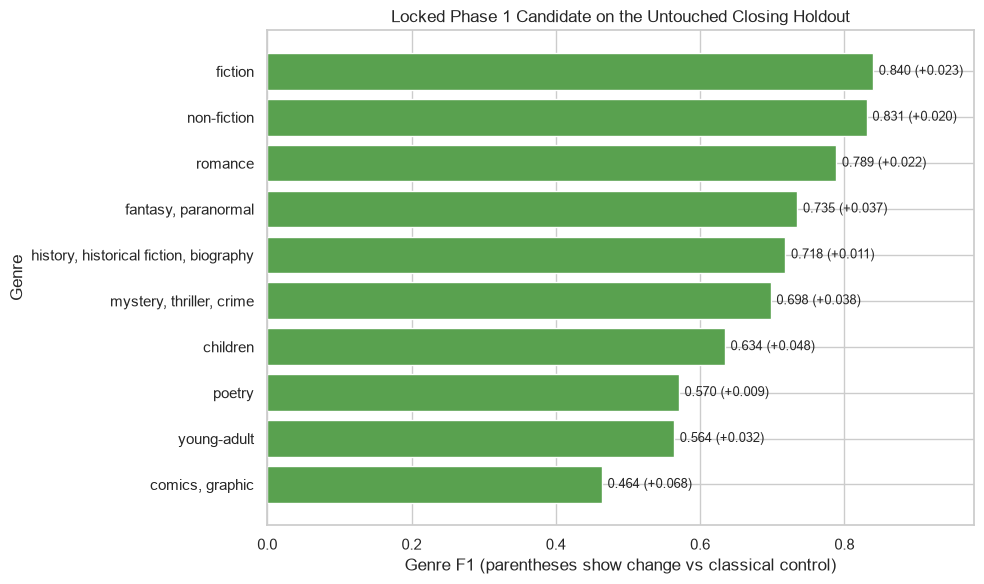

In [15]:
# Color genre bars by the direction of change so the aggregate result remains interpretable.
selected_genre_plot = final_holdout_per_genre.loc[
    final_holdout_per_genre["candidate"].str.startswith("Locked")
].sort_values("f1", ascending=True)
plt.figure(figsize=(10, 6))
colors = np.where(selected_genre_plot["f1_delta_vs_classical"] >= 0, "#59A14F", "#E15759")
plt.barh(selected_genre_plot["genre"], selected_genre_plot["f1"], color=colors)
for position, row in enumerate(selected_genre_plot.itertuples(index=False)):
    plt.text(
        row.f1 + 0.008,
        position,
        f"{row.f1:.3f} ({row.f1_delta_vs_classical:+.3f})",
        va="center",
        fontsize=9,
    )
plt.xlim(0, min(1.0, max(0.75, selected_genre_plot["f1"].max() + 0.14)))
plt.title("Locked Phase 1 Candidate on the Untouched Closing Holdout")
plt.xlabel("Genre F1 (parentheses show change vs classical control)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "closing_holdout_per_genre.png", dpi=160, bbox_inches="tight")
plt.show()


## 9. Export the Phase 1 evidence package

Compact reports retain fold variability, calibration choices, guardrail diagnostics, one-time closing-holdout results, and reproducibility metadata. Long row-level errors are saved rather than displayed, and the model artifact records only the pipeline that was locked before holdout access.


In [16]:
# Export compact evidence tables and a manifest while keeping long row-level errors out of notebook output.
final_threshold_table = pd.DataFrame(
    {"genre": TARGET_GENRES, "decision_threshold": selected_thresholds}
)
# Separate smoke, development evaluation, and final fitting costs for honest operational comparison.
runtime_inventory = pd.DataFrame(
    [
        {
            "stage": "Fine-tuning smoke test",
            "seconds": smoke_log["training_seconds"],
            "device": DEVICE,
            "detail": f"{smoke_log['optimizer_steps']} optimizer steps",
        },
        {
            "stage": "Development candidate evaluation",
            "seconds": float(all_fold_results["fit_seconds"].sum()),
            "device": DEVICE,
            "detail": f"{OUTER_CV_SPLITS} outer folds",
        },
        {
            "stage": "Final fitting and closing evaluation",
            "seconds": final_fit_seconds,
            "device": DEVICE,
            "detail": SELECTED_CANDIDATE,
        },
    ]
)

# Map stable filenames to compact evidence tables so reruns overwrite a coherent versioned package.
artifact_tables = {
    "notebook07_cv_fold_results.csv": all_fold_results,
    "notebook07_fusion_grid_search.csv": fusion_search_results,
    "notebook07_fusion_fold_parameters.csv": fusion_parameters.drop(
        columns=[
            "classical_score_mean", "classical_score_scale",
            "e5_score_mean", "e5_score_scale", "fusion_thresholds",
        ]
    ),
    "notebook07_fine_tuning_thresholds.csv": fine_tuning_thresholds,
    "notebook07_candidate_summary.csv": candidate_summary,
    "notebook07_candidate_selection.csv": candidate_selection,
    "notebook07_oof_per_genre.csv": per_genre_oof,
    "notebook07_oof_language_slices.csv": language_slices,
    "notebook07_final_holdout_metrics.csv": final_holdout_metrics,
    "notebook07_final_holdout_per_genre.csv": final_holdout_per_genre,
    "notebook07_final_holdout_errors.csv": final_holdout_errors,
    "notebook07_final_thresholds.csv": final_threshold_table,
    "notebook07_runtime_inventory.csv": runtime_inventory,
}
for filename, table in artifact_tables.items():
    table.to_csv(REPORTS_DIR / filename, index=False)

# Record selection boundaries, fingerprints, configuration, and the one-time holdout decision together.
experiment_manifest = {
    "notebook": "07_advanced_multilabel_genre_classification_and_phase1_synthesis",
    "phase": "Research Lane Phase 1",
    "status_after_execution": "Phase 1 classification evidence complete",
    "random_state": RANDOM_STATE,
    "development_fingerprint": DEVELOPMENT_FINGERPRINT,
    "closing_holdout_fingerprint": CLOSING_HOLDOUT_FINGERPRINT,
    "development_books": len(development),
    "closing_holdout_books": len(closing_analysis),
    "outer_cv_splits": OUTER_CV_SPLITS,
    "inner_cv_splits": INNER_CV_SPLITS,
    "primary_metric": "Macro F1",
    "material_gain_threshold": MATERIAL_MACRO_F1_GAIN,
    "maximum_guardrail_decline": MAX_GUARDRAIL_DECLINE,
    "selected_candidate": SELECTED_CANDIDATE,
    "selected_threshold_policy": selected_policy,
    "selected_model_artifact": str(selected_artifact_path),
    "selected_model_metadata": selected_metadata,
    "closing_macro_f1_gain_vs_classical": float(final_holdout_gain),
    "notebook06_test_reused": False,
    "closing_holdout_opened_after_selection": True,
    "target_genres": TARGET_GENRES,
    "training_configuration": training_configuration,
    "phase2_semantic_neighbor_work": "Deferred",
}
manifest_path = MODELS_DIR / "notebook07_experiment_manifest_v3.json"
manifest_path.write_text(
    json.dumps(experiment_manifest, indent=2, sort_keys=True), encoding="utf-8"
)

# Summarize artifact groups rather than printing long report contents in the notebook.
artifact_inventory = pd.DataFrame(
    [
        {"artifact_group": "Reports", "count": len(artifact_tables), "location": str(REPORTS_DIR)},
        {"artifact_group": "Figures", "count": 4, "location": str(FIGURES_DIR)},
        {"artifact_group": "Selected model", "count": 1, "location": str(selected_artifact_path)},
        {"artifact_group": "Manifest", "count": 1, "location": str(manifest_path)},
        {"artifact_group": "Closing cohort", "count": 3, "location": str(INTERIM_DIR)},
    ]
)
display(artifact_inventory)


,artifact_group,count,location
0,Reports,13,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports
1,Figures,4,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/figures/notebook07
2,Selected model,1,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook07/se...
3,Manifest,1,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook07/no...
4,Closing cohort,3,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim


## 10. Phase 1 synthesis checkpoint

The next cell renders a concise measured handoff from the executed objects. After the notebook has run successfully and its artifacts have been reviewed, replace this dynamic checkpoint with a static Markdown conclusion so Phase 1 can be resumed without executing code.


In [17]:
# Render a concise measured handoff from already computed results; this cell performs no new selection.
selected_cv = candidate_selection.loc[
    candidate_selection["candidate"].eq(SELECTED_CANDIDATE)
].iloc[0]
selected_holdout = final_holdout_metrics.iloc[1]
classical_holdout = final_holdout_metrics.iloc[0]
weakest_genres = (
    final_holdout_per_genre.loc[
        final_holdout_per_genre["candidate"].str.startswith("Locked")
    ]
    .nsmallest(3, "f1")[["genre", "f1"]]
)
weakest_text = ", ".join(
    f"{row.genre} ({row.f1:.3f})" for row in weakest_genres.itertuples(index=False)
)

display(
    Markdown(
        f"""
        ### Measured Phase 1 handoff

        - **Locked candidate:** {SELECTED_CANDIDATE}.
        - **Development evidence:** grouped CV Macro F1 **{selected_cv['cv_macro_f1_mean']:.4f} ± {selected_cv['cv_macro_f1_std']:.4f}**, a **{selected_cv['macro_f1_gain_vs_classical']:+.4f}** change from the frozen classical mean.
        - **Guardrails:** worst rare-genre change **{selected_cv['worst_rare_genre_f1_delta']:+.4f}**; worst sufficiently large language-slice change **{selected_cv['worst_language_macro_f1_delta']:+.4f}**.
        - **Untouched closing holdout:** selected Macro F1 **{selected_holdout['macro_f1']:.4f}** versus classical **{classical_holdout['macro_f1']:.4f}**, a **{final_holdout_gain:+.4f}** difference. The holdout is now closed to further selection.
        - **Weakest closing-holdout genres:** {weakest_text}.
        - **Decision boundary:** Phase 1 classification experimentation is complete regardless of whether the advanced candidate improved. Any future classification work must be motivated by a new label-quality question or data source, not further tuning on this holdout.
        - **Next research phase:** begin Phase 2 by revisiting the parked semantic-neighbor pilot and choosing whether semantic search, recommendation, or exploratory discovery defines the human-relevance rubric.
        """
    )
)



        ### Measured Phase 1 handoff

        - **Locked candidate:** Classical + E5 fusion.
        - **Development evidence:** grouped CV Macro F1 **0.6746 ± 0.0027**, a **+0.0299** change from the frozen classical mean.
        - **Guardrails:** worst rare-genre change **+0.0284**; worst sufficiently large language-slice change **+0.0222**.
        - **Untouched closing holdout:** selected Macro F1 **0.6842** versus classical **0.6535**, a **+0.0307** difference. The holdout is now closed to further selection.
        - **Weakest closing-holdout genres:** comics, graphic (0.464), young-adult (0.564), poetry (0.570).
        - **Decision boundary:** Phase 1 classification experimentation is complete regardless of whether the advanced candidate improved. Any future classification work must be motivated by a new label-quality question or data source, not further tuning on this holdout.
        - **Next research phase:** begin Phase 2 by revisiting the parked semantic-neighbor pilot and choosing whether semantic search, recommendation, or exploratory discovery defines the human-relevance rubric.
        